# D1 (Sepsis) Benchmark Visualization

Reads all `Sepsis__*.json` from `benchmark/results/configs_v2/` and generates four complementary views.

| Figure | Type | Content |
|--------|------|---------|
| **1. Master Heatmap** | Heatmap | All 15 methods × 8 miners |
| **2. M1 Family Evolution** | Line chart | M1a→M1g across 8 miners |
| **3. Headline Comparison** | Grouped bar chart | M1g vs M2/M3/M5/M6/M7/R1/R2/R3 |
| **4. Dual-Pole Validation** | Bar chart | Flower (≈1.0) and Trace\_Filtered (should be low) across all methods |

---

In [14]:
import json, glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
%matplotlib inline

# === Paths ===
CONFIG_DIR = "../../benchmark/results/configs_v2/"

print(f"Config dir: {CONFIG_DIR}")

Config dir: ../../benchmark/results/configs_v2/


---
## 1. Load Data

In [15]:
# === Load all D1 (Sepsis) JSONs ===
files = sorted(glob.glob(os.path.join(CONFIG_DIR, "Sepsis__*.json")))
print(f"Found {len(files)} config files for Sepsis")

records = []
for fp in files:
    basename = os.path.basename(fp)
    # Parse dataset__miner__method from filename
    match = re.match(r'Sepsis__(.+)__(M\d[^.]*|R\d)?.json', basename)
    if not match:
        # handle cases like R1, R2, R3
        match = re.match(r'Sepsis__(.+)__(R\d).json', basename)
    with open(fp, 'r') as f:
        data = json.load(f)
    
    miner = data['miner']
    method = data['method']
    method_label = data.get('method_label', method)
    
    # Extract mean value (handle varied result structures)
    results = data.get('results', {})
    mean = results.get('mean', None)
    std = results.get('std', None)
    
    # M3 special: use entropic_relevance_raw
    if mean is None and 'entropic_relevance_raw' in results:
        mean = results['entropic_relevance_raw']
    
    # M5 Trace_Filtered special: use score field
    if mean is None and 'score' in results:
        mean = results['score']
        std = 0.0  # single run, no std
    
    # M6/M7 special: use gen_score field
    if mean is None and 'gen_score' in results:
        mean = results['gen_score']
        if 'std' not in results or results['std'] is None:
            std = 0.0
    
    records.append({
        'miner': miner,
        'method': method,
        'method_label': method_label,
        'mean': mean,
        'std': std,
        'file': basename
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} records ({df['method'].nunique()} methods × {df['miner'].nunique()} miners)")
print(f"\nMethods: {sorted(df['method'].unique())}")
print(f"Miners:  {sorted(df['miner'].unique())}")

Found 120 config files for Sepsis
Loaded 120 records (15 methods × 8 miners)

Methods: ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g', 'M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']
Miners:  ['Alpha', 'Alpha+', 'Flower', 'Heuristics', 'Heuristics_Strict', 'Inductive_Infrequent', 'Inductive_Strict', 'Trace_Filtered']


In [16]:
# === Check for missing values ===
pivot_check = df.pivot_table(index='miner', columns='method', values='mean', aggfunc='first')
missing = pivot_check.isna().sum().sum()
print(f"Missing values: {missing}")
if missing > 0:
    print("\nMissing cells:")
    for method in pivot_check.columns:
        na_miners = pivot_check.index[pivot_check[method].isna()].tolist()
        if na_miners:
            print(f"  {method}: {na_miners}")

df.head(3)

Missing values: 0


,miner,method,method_label,mean,std,file
0,Alpha+,M1a,HybridGen v1 (1-gram DFG),0.606224,0.004173,Sepsis__Alpha+__M1a.json
1,Alpha+,M1b,HybridGen v2.1 (N=3),0.552151,0.002918,Sepsis__Alpha+__M1b.json
2,Alpha+,M1c,HybridGen v2.1 (N=6),0.627083,0.005629,Sepsis__Alpha+__M1c.json


---
## 2. Data Preprocessing

### Define Display Order

In [17]:
# === Canonical miner order (0.0 pole → 1.0 pole) ===
MINER_ORDER = [
    'Trace_Filtered',   # 0.0 pole: pure memorization
    'Alpha',
    'Alpha+',
    'Heuristics',
    'Heuristics_Strict',
    'Inductive_Strict',
    'Inductive_Infrequent',
    'Flower',           # 1.0 pole: accepts everything
]

# === Method group order ===
METHOD_ORDER_M1 = ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g']
METHOD_ORDER_ALL = METHOD_ORDER_M1 + ['M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']

METHOD_GROUPS = {
    'HybridGen (M1)': ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g'],
    'External': ['M2', 'M3', 'M5', 'M6', 'M7'],
    'Reference': ['R1', 'R2', 'R3'],
}

# === Method label mapping (for display) ===
METHOD_LABELS = {
    'M1a': 'M1a\nv1.0',
    'M1b': 'M1b\nv2.1 N=3',
    'M1c': 'M1c\nv2.1 N=6',
    'M1d': 'M1d\nv2.4',
    'M1e': 'M1e\nv2.5',
    'M1f': 'M1f\nv2.6 log',
    'M1g': 'M1g\nv2.6 MLE',
    'M2': 'M2\nPM4Py',
    'M3': 'M3\nEntropic',
    'M5': 'M5\nAVATAR',
    'M6': 'M6\nBootstrap',
    'M7': 'M7\nSpeciAL',
    'R1': 'R1\nK-Fold CV',
    'R2': 'R2\nLOVO',
    'R3': 'R3\nRandom',
}

MINER_LABELS = {
    'Trace_Filtered': 'Trace\nFiltered',
    'Alpha': 'Alpha',
    'Alpha+': 'Alpha+',
    'Heuristics': 'Heuristics',
    'Heuristics_Strict': 'Heuristics\nStrict',
    'Inductive_Strict': 'Inductive\nStrict',
    'Inductive_Infrequent': 'Inductive\nInfrequent',
    'Flower': 'Flower',
}

# Validate existence
present_miners = set(df['miner'].unique())
present_methods = set(df['method'].unique())
for m in MINER_ORDER:
    assert m in present_miners, f"Miner '{m}' not found in data!"
for m in METHOD_ORDER_ALL:
    assert m in present_methods, f"Method '{m}' not found in data!"
print("✓ All miner/method definitions validated")

✓ All miner/method definitions validated


In [18]:
# === Build Pivot Table (mean values) ===
pivot = df.pivot_table(index='miner', columns='method', values='mean', aggfunc='first')
pivot = pivot.reindex(index=MINER_ORDER, columns=METHOD_ORDER_ALL)

# Same for std
pivot_std = df.pivot_table(index='miner', columns='method', values='std', aggfunc='first')
pivot_std = pivot_std.reindex(index=MINER_ORDER, columns=METHOD_ORDER_ALL)

print("=== Mean Values ===")
display(pivot.round(4))
print("\n=== Std Values ===")
display(pivot_std.round(4))

=== Mean Values ===


method,M1a,M1b,M1c,M1d,M1e,M1f,M1g,M2,M3,M5,M6,M7,R1,R2,R3
miner,,,,,,,,,,,,,,,
Trace_Filtered,0.5620,0.4956,0.5173,0.5106,0.5085,0.5085,0.5687,0.0285,29.8692,0.0000,0.4558,1.0000,0.6411,0.6058,0.2796
Alpha,0.2654,0.2841,0.2968,0.2881,0.2849,0.2849,0.2724,0.9132,29.8692,0.3401,0.0000,0.7989,0.2748,0.3059,0.2779
Alpha+,0.6062,0.5522,0.6271,0.6277,0.6512,0.6512,0.7591,0.9189,29.8692,0.5617,0.1876,0.7500,0.8293,0.7753,0.3820
Heuristics,0.8651,0.8214,0.8355,0.8317,0.8457,0.8457,0.8787,0.8298,29.8692,0.7460,0.3435,1.0000,0.9023,0.8700,0.5024
Heuristics_Strict,0.8929,0.8465,0.8535,0.8512,0.8640,0.8640,0.9174,0.9004,29.8692,0.7044,0.3225,0.9983,0.9329,0.9175,0.6212
Inductive_Strict,0.9753,0.9423,0.9557,0.9574,0.9613,0.9613,0.9838,0.9025,29.8692,0.5347,0.2327,0.7443,0.9999,1.0000,0.7667
Inductive_Infrequent,0.9107,0.8901,0.9161,0.9200,0.9310,0.9310,0.9723,0.8799,29.8692,0.7506,0.2796,0.7500,0.9846,0.9813,0.6930
Flower,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9132,29.8692,0.3967,0.1826,0.8034,1.0000,1.0000,1.0000



=== Std Values ===


method,M1a,M1b,M1c,M1d,M1e,M1f,M1g,M2,M3,M5,M6,M7,R1,R2,R3
miner,,,,,,,,,,,,,,,
Trace_Filtered,0.0026,0.0062,0.0054,0.0039,0.0015,0.0015,0.0030,0.0,NaN,0.0000,0.0,0.0,0.0092,0.0947,0.0033
Alpha,0.0028,0.0027,0.0031,0.0026,0.0054,0.0054,0.0039,0.0,NaN,0.0203,0.0,0.0,0.0014,0.0752,0.0035
Alpha+,0.0042,0.0029,0.0056,0.0044,0.0119,0.0119,0.0053,0.0,NaN,0.0081,0.0,0.0,0.0017,0.1765,0.0036
Heuristics,0.0023,0.0019,0.0012,0.0029,0.0027,0.0027,0.0017,0.0,NaN,0.0014,0.0,0.0,0.0054,0.0507,0.0050
Heuristics_Strict,0.0021,0.0013,0.0006,0.0030,0.0022,0.0022,0.0015,0.0,NaN,0.0015,0.0,0.0,0.0010,0.0436,0.0034
Inductive_Strict,0.0015,0.0016,0.0016,0.0009,0.0029,0.0029,0.0020,0.0,NaN,0.0092,0.0,0.0,0.0000,0.0000,0.0018
Inductive_Infrequent,0.0004,0.0006,0.0014,0.0033,0.0025,0.0025,0.0019,0.0,NaN,0.0023,0.0,0.0,0.0024,0.0532,0.0015
Flower,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,NaN,0.0074,0.0,0.0,0.0000,0.0000,0.0000


In [19]:
# === M3: keep raw value, do NOT normalize ===
# M3 (Entropic Relevance) is DFG-based — same raw value across all miners, unbounded.
# Cross-dataset min-max normalization will be applied once D2–D5 are available.
# For now, keep the raw value; the heatmap will cap M3 at 1.0 for coloring
# while annotations show the actual raw value.
pivot_norm = pivot.copy()

m3_raw = pivot['M3'].iloc[0]
m3_note = f"M3: raw entropic relevance ({m3_raw:.2f}), DFG-based — same for all miners"

print(m3_note)
print(f"\nValue range per method:")
for col in pivot_norm.columns:
    vals = pivot_norm[col].dropna()
    print(f"  {col:4s}: [{vals.min():.4f}, {vals.max():.4f}]")

M3: raw entropic relevance (29.87), DFG-based — same for all miners

Value range per method:
  M1a : [0.2654, 1.0000]
  M1b : [0.2841, 1.0000]
  M1c : [0.2968, 1.0000]
  M1d : [0.2881, 1.0000]
  M1e : [0.2849, 1.0000]
  M1f : [0.2849, 1.0000]
  M1g : [0.2724, 1.0000]
  M2  : [0.0285, 0.9189]
  M3  : [29.8692, 29.8692]
  M5  : [0.0000, 0.7506]
  M6  : [0.0000, 0.4558]
  M7  : [0.7443, 1.0000]
  R1  : [0.2748, 1.0000]
  R2  : [0.3059, 1.0000]
  R3  : [0.2779, 1.0000]


---
## 3. Figure 1: Master Heatmap

All 15 methods × 8 miners. Colormap mapped to [0, 1] (M3 normalized for display).

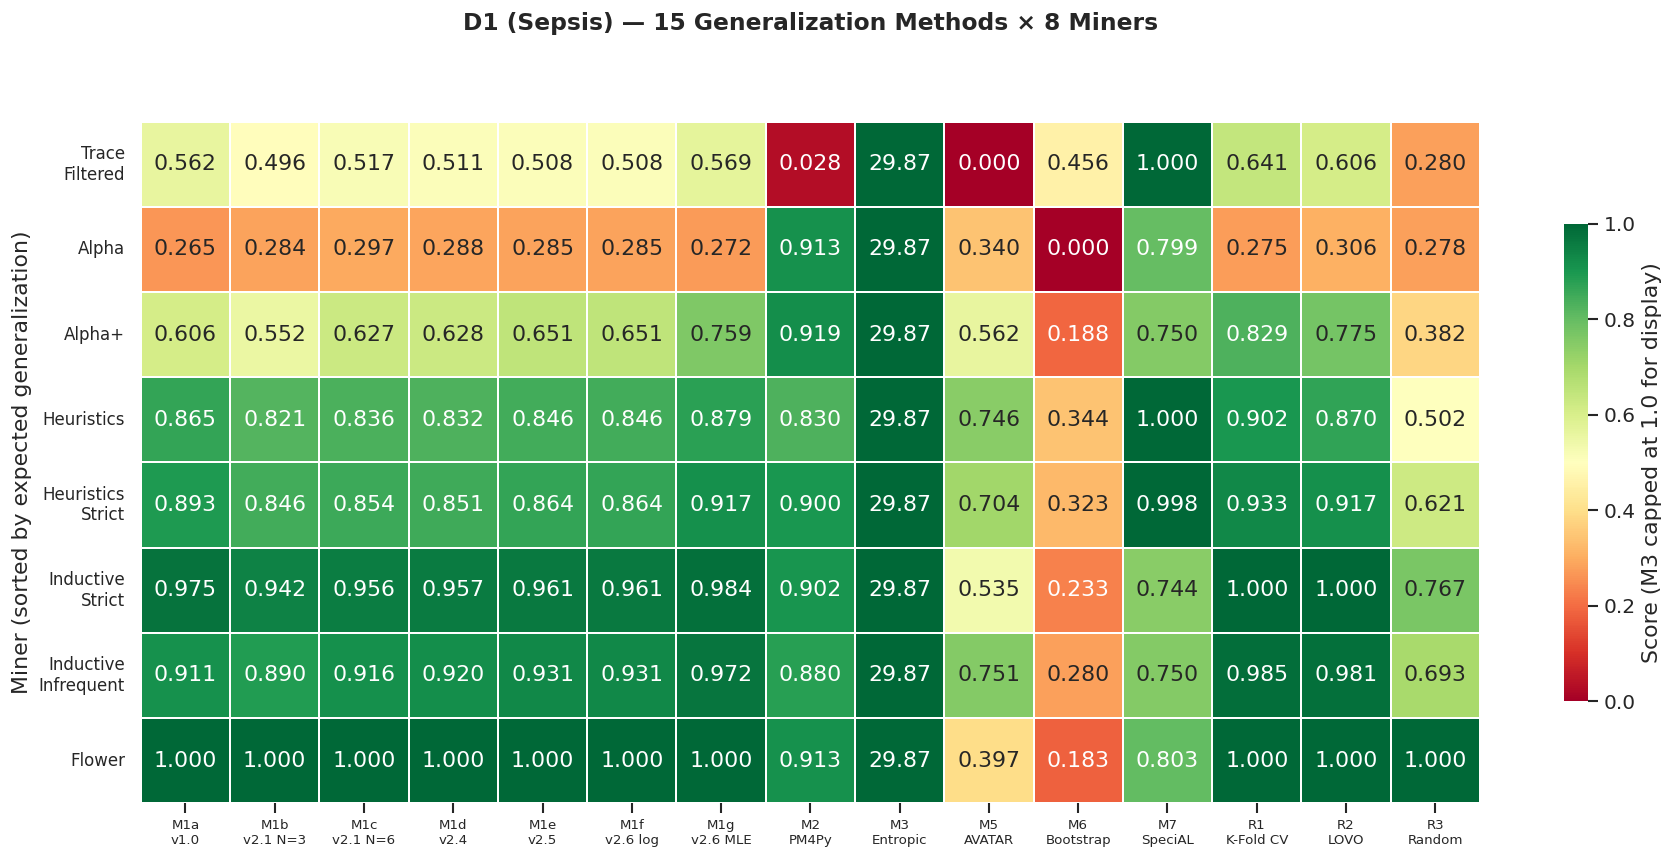

In [20]:
# === Figure 1: Master Heatmap ===
fig, ax = plt.subplots(figsize=(18, 8))

# Annotation text: show mean ± std; M3 shows raw value + "(DFG)"
annot_data = np.empty_like(pivot_norm.values, dtype=object)
for i, miner in enumerate(pivot_norm.index):
    for j, method in enumerate(pivot_norm.columns):
        val = pivot_norm.iloc[i, j]
        if pd.isna(val):
            annot_data[i, j] = ""
            continue
        std_val = pivot_std.iloc[i, j] if not pd.isna(pivot_std.iloc[i, j]) else None
        
        if method == 'M3':
            # Show raw entropic relevance (DFG-based, not on [0,1] scale)
            raw_val = pivot.iloc[i, j]
            annot_data[i, j] = f"{raw_val:.2f}"
        # elif std_val is not None and not np.isnan(std_val):
        #     annot_data[i, j] = f"{val:.3f}\n±{std_val:.3f}"
        else:
            annot_data[i, j] = f"{val:.3f}"

# Colormap
cmap = sns.color_palette("RdYlGn", as_cmap=True)

# Use a separate df for coloring: cap M3 at 1.0 so its unbounded raw value
# doesn't compress the [0,1] color scale for all other methods
pivot_cmap = pivot_norm.copy()
pivot_cmap['M3'] = pivot_cmap['M3'].clip(upper=1.0)

sns.heatmap(
    pivot_cmap, 
    annot=annot_data, 
    fmt='',
    cmap=cmap,
    vmin=0, vmax=1,
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Score (M3 capped at 1.0 for display)', 'shrink': 0.7},
    ax=ax
)

# Miner labels (y-axis)
ax.set_yticklabels([MINER_LABELS.get(m, m) for m in pivot_norm.index], rotation=0, fontsize=10)
ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in pivot_norm.columns], rotation=0, fontsize=8)

# Column group headers placed above the heatmap (y = n_rows + offset)
# Move x-axis ticks to bottom so top is free for group labels
ax.xaxis.set_ticks_position('bottom')
n_rows = len(pivot_norm.index)  # = 8
# group_boundaries = [0, 7, 12, 15]  # M1(7) + External(5) + Reference(3)
# group_labels = ['HybridGen\n(M1a–M1g)', 'External\n(M2–M7)', 'Reference\n(R1–R3)']
# for idx, (start, end) in enumerate(zip(group_boundaries[:-1], group_boundaries[1:])):
#     mid = (start + end) / 2 - 0.5
#     ax.text(mid, n_rows + 0.65, group_labels[idx], 
#             ha='center', va='bottom', fontsize=10, fontweight='bold',
#             color='#333')

ax.set_title('D1 (Sepsis) — 15 Generalization Methods × 8 Miners', fontsize=14, fontweight='bold', pad=55)
ax.set_xlabel('')
ax.set_ylabel('Miner (sorted by expected generalization)')

plt.subplots_adjust(top=0.82)
plt.show()

---
## 4. Figure 2: M1 Family Evolution

Traces M1a→M1g (v1.0 → v2.6 MLE) across all 8 miners.

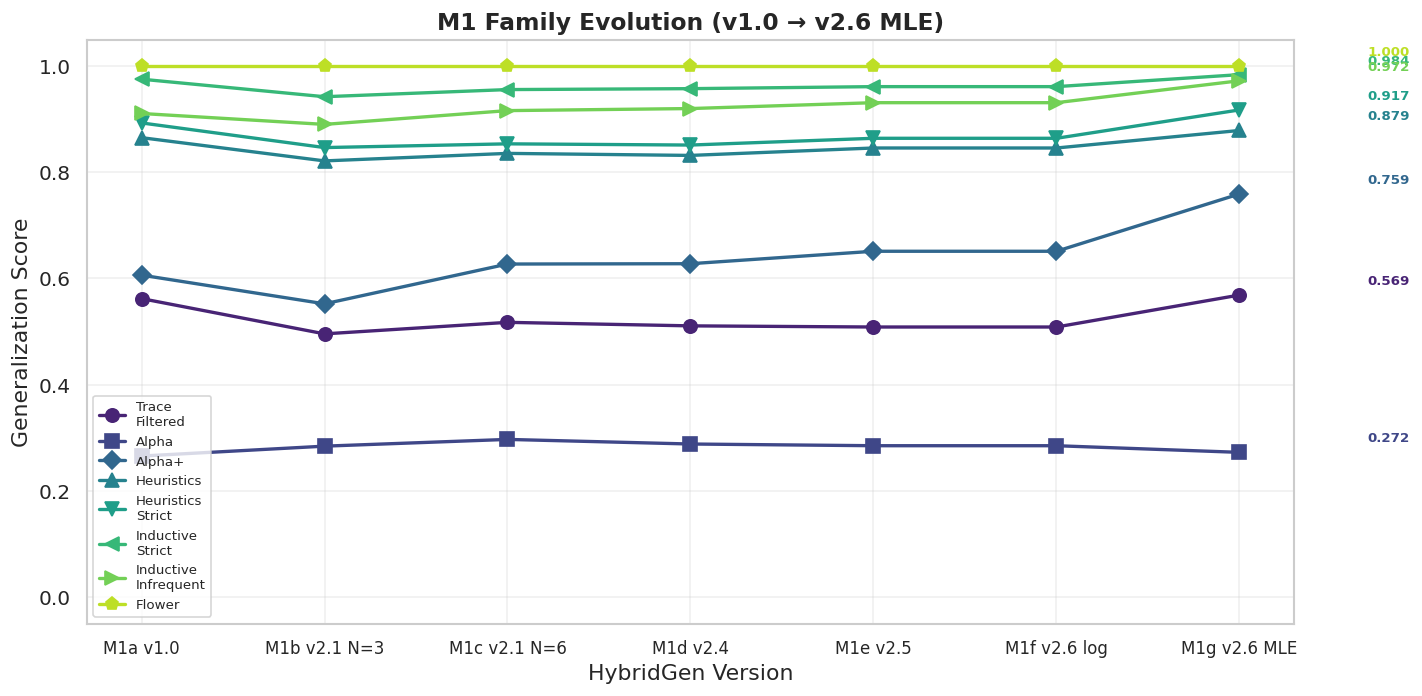

In [21]:
# === Figure 2: M1 Family Evolution Line Chart ===
fig, ax = plt.subplots(figsize=(12, 6))

# M1 subset
m1_pivot = pivot_norm.loc[MINER_ORDER, METHOD_ORDER_M1]

# Color map by miner
miner_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(MINER_ORDER)))
miner_styles = ['o', 's', 'D', '^', 'v', '<', '>', 'p']

x = range(len(METHOD_ORDER_M1))

for idx, miner in enumerate(MINER_ORDER):
    vals = m1_pivot.loc[miner].values
    ax.plot(x, vals, 
            marker=miner_styles[idx % len(miner_styles)], 
            color=miner_colors[idx],
            linewidth=2, markersize=8,
            label=MINER_LABELS.get(miner, miner))
    # Annotate endpoint value
    ax.annotate(f'{vals[-1]:.3f}', 
                xy=(len(x)-1, vals[-1]),
                xytext=(len(x)-0.3, vals[-1] + 0.02),
                fontsize=8, color=miner_colors[idx], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABELS[m].replace('\n', ' ') for m in METHOD_ORDER_M1], fontsize=10)
ax.set_xlabel('HybridGen Version')
ax.set_ylabel('Generalization Score')
ax.set_title('M1 Family Evolution (v1.0 → v2.6 MLE)', fontsize=14, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower left', fontsize=8, ncol=1, framealpha=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### Figure 2b: M1 Family MAE vs R1 (K-Fold CV)

Mean Absolute Error between each M1 variant and R1, averaged across all 8 miners.
Lower MAE = better agreement with the cross-validation reference.

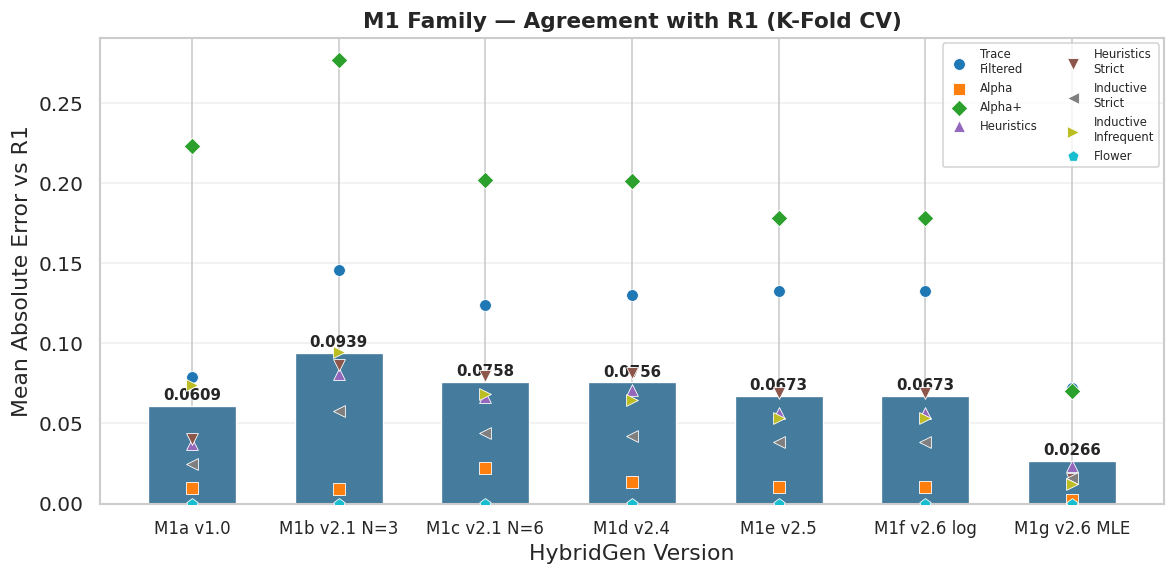

In [22]:
# === Figure 2b: M1 Family MAE vs R1 ===
# Compute per-miner Absolute Error between each M1 variant and R1
r1_vals = pivot.loc[MINER_ORDER, 'R1'].values  # shape (8,)
m1_ae = {}  # miner -> array of 7 AE values
for m1 in METHOD_ORDER_M1:
    m1_vals = pivot.loc[MINER_ORDER, m1].values
    ae = np.abs(m1_vals - r1_vals)
    m1_ae[m1] = ae

# Aggregate: MAE across miners for each M1 variant
mae_by_variant = {m1: np.mean(m1_ae[m1]) for m1 in METHOD_ORDER_M1}

# Also per-miner AE for scatter overlay
ae_df = pd.DataFrame(m1_ae, index=MINER_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(METHOD_ORDER_M1))
bar_width = 0.6

mae_vals = [mae_by_variant[m] for m in METHOD_ORDER_M1]
bars = ax.bar(x, mae_vals, bar_width, color='#457B9D', edgecolor='white', linewidth=0.8)

# Annotate bars
for i, v in enumerate(mae_vals):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Overlay per-miner scatter
miner_markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p']
miner_colors = plt.cm.tab10(np.linspace(0, 1, len(MINER_ORDER)))
for mi, miner in enumerate(MINER_ORDER):
    ax.scatter(x, ae_df.loc[miner].values,
               marker=miner_markers[mi], color=miner_colors[mi],
               s=50, zorder=5, edgecolors='white', linewidth=0.5,
               label=MINER_LABELS.get(miner, miner))

ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABELS[m].replace('\n', ' ') for m in METHOD_ORDER_M1], fontsize=10)
ax.set_xlabel('HybridGen Version')
ax.set_ylabel('Mean Absolute Error vs R1')
ax.set_title('M1 Family — Agreement with R1 (K-Fold CV)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.8)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Figure 3: Headline Comparison

M1g (v2.6 MLE, headline candidate) vs external methods & reference baselines. One grouped bar cluster per miner.

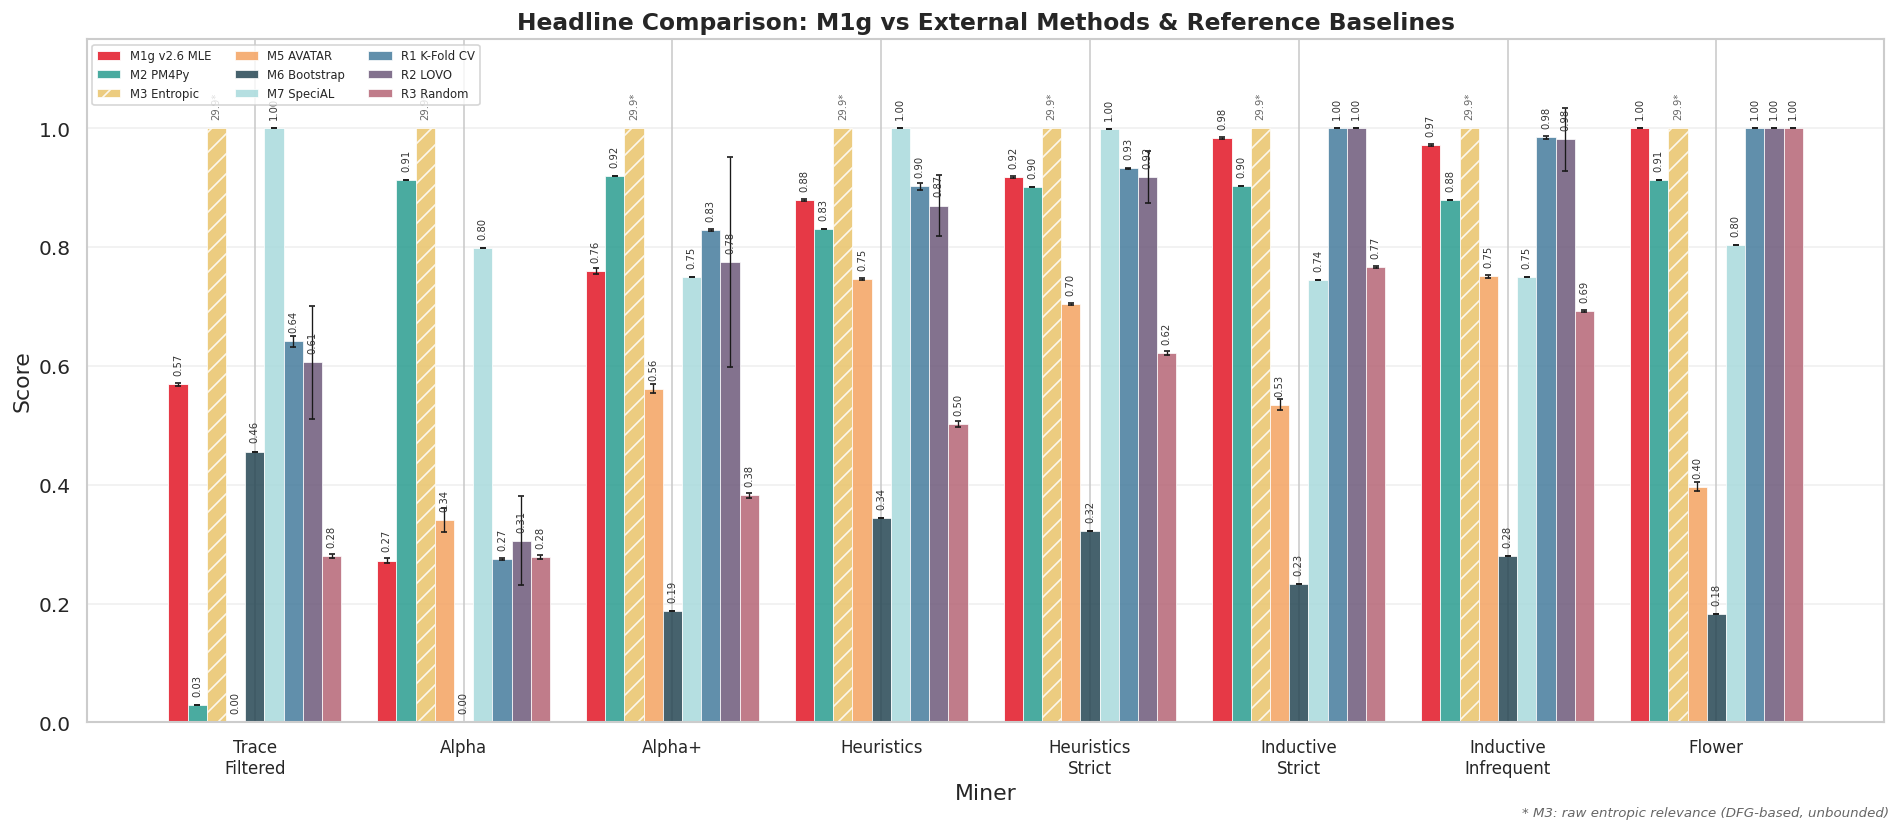

In [23]:
# === Figure 3: Headline Comparison Grouped Bar Chart ===
HEADLINE_METHODS = ['M1g', 'M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']

# For display: cap M3 at 1.0 so the y-axis remains [0,1] readable
hl_pivot_cmap = pivot_norm.loc[MINER_ORDER, HEADLINE_METHODS].copy()
hl_pivot_cmap['M3'] = hl_pivot_cmap['M3'].clip(upper=1.0)

hl_pivot_std = pivot_std.loc[MINER_ORDER, HEADLINE_METHODS]

# Color: distinct color per method; M1g highlighted in red
palette_colors = {
    'M1g': '#E63946',
    'M2': '#2A9D8F',
    'M3': '#E9C46A',
    'M5': '#F4A261',
    'M6': '#264653',
    'M7': '#A8DADC',
    'R1': '#457B9D',
    'R2': '#6D597A',
    'R3': '#B56576',
}

fig, ax = plt.subplots(figsize=(16, 7))

n_miners = len(MINER_ORDER)
n_methods = len(HEADLINE_METHODS)
bar_width = 0.08
group_gap = 0.15

x_base = np.arange(n_miners) * (n_methods * bar_width + group_gap)

for j, method in enumerate(HEADLINE_METHODS):
    x_pos = x_base + j * bar_width
    vals = hl_pivot_cmap[method].values
    errs = hl_pivot_std[method].values
    
    # M3 gets a distinct hatch pattern to signal it's DFG-based
    hatch = '//' if method == 'M3' else ''
    
    bars = ax.bar(x_pos, vals, bar_width,
                  label=METHOD_LABELS.get(method, method).replace('\n', ' '),
                  color=palette_colors[method],
                  alpha=0.85 if j > 0 else 1.0,
                  edgecolor='white', linewidth=0.5,
                  yerr=errs, capsize=2, error_kw={'elinewidth': 0.8},
                  hatch=hatch)
    
    # Annotate value above each bar
    for i, (val, err) in enumerate(zip(vals, errs)):
        if not pd.isna(val):
            # M3: show raw value in annotation
            if method == 'M3':
                raw_val = pivot.loc[MINER_ORDER[i], 'M3']
                ax.text(x_pos[i], val + 0.015, f'{raw_val:.1f}*',
                        ha='center', va='bottom', fontsize=6, rotation=90, color='#666')
            else:
                ax.text(x_pos[i], val + 0.015, f'{val:.2f}',
                        ha='center', va='bottom', fontsize=6, rotation=90, color='#333')

ax.set_xticks(x_base + (n_methods - 1) * bar_width / 2)
ax.set_xticklabels([MINER_LABELS.get(m, m) for m in MINER_ORDER], fontsize=10)
ax.set_xlabel('Miner')
ax.set_ylabel('Score')
ax.set_title('Headline Comparison: M1g vs External Methods & Reference Baselines',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=7, ncol=3, framealpha=0.8)
ax.set_ylim(0, 1.15)
ax.grid(True, axis='y', alpha=0.3)

# Add note about M3
fig.text(0.99, 0.01, '* M3: raw entropic relevance (DFG-based, unbounded)',
         ha='right', va='bottom', fontsize=8, color='#666', fontstyle='italic')

plt.tight_layout()
plt.show()

---
## 6. Figure 4: Dual-Pole Validation

Checks construct validity:
- **Flower** (1.0 pole): all methods should score ≈ 1.0 (a pure-generalization metric should rank the maximally-permissive model highest)
- **Trace\_Filtered** (0.0 pole, pure memorization): all methods should score low

If a method scores Flower substantially < 0.8 or Trace\_Filtered substantially > 0.4, its construct validity is questionable.

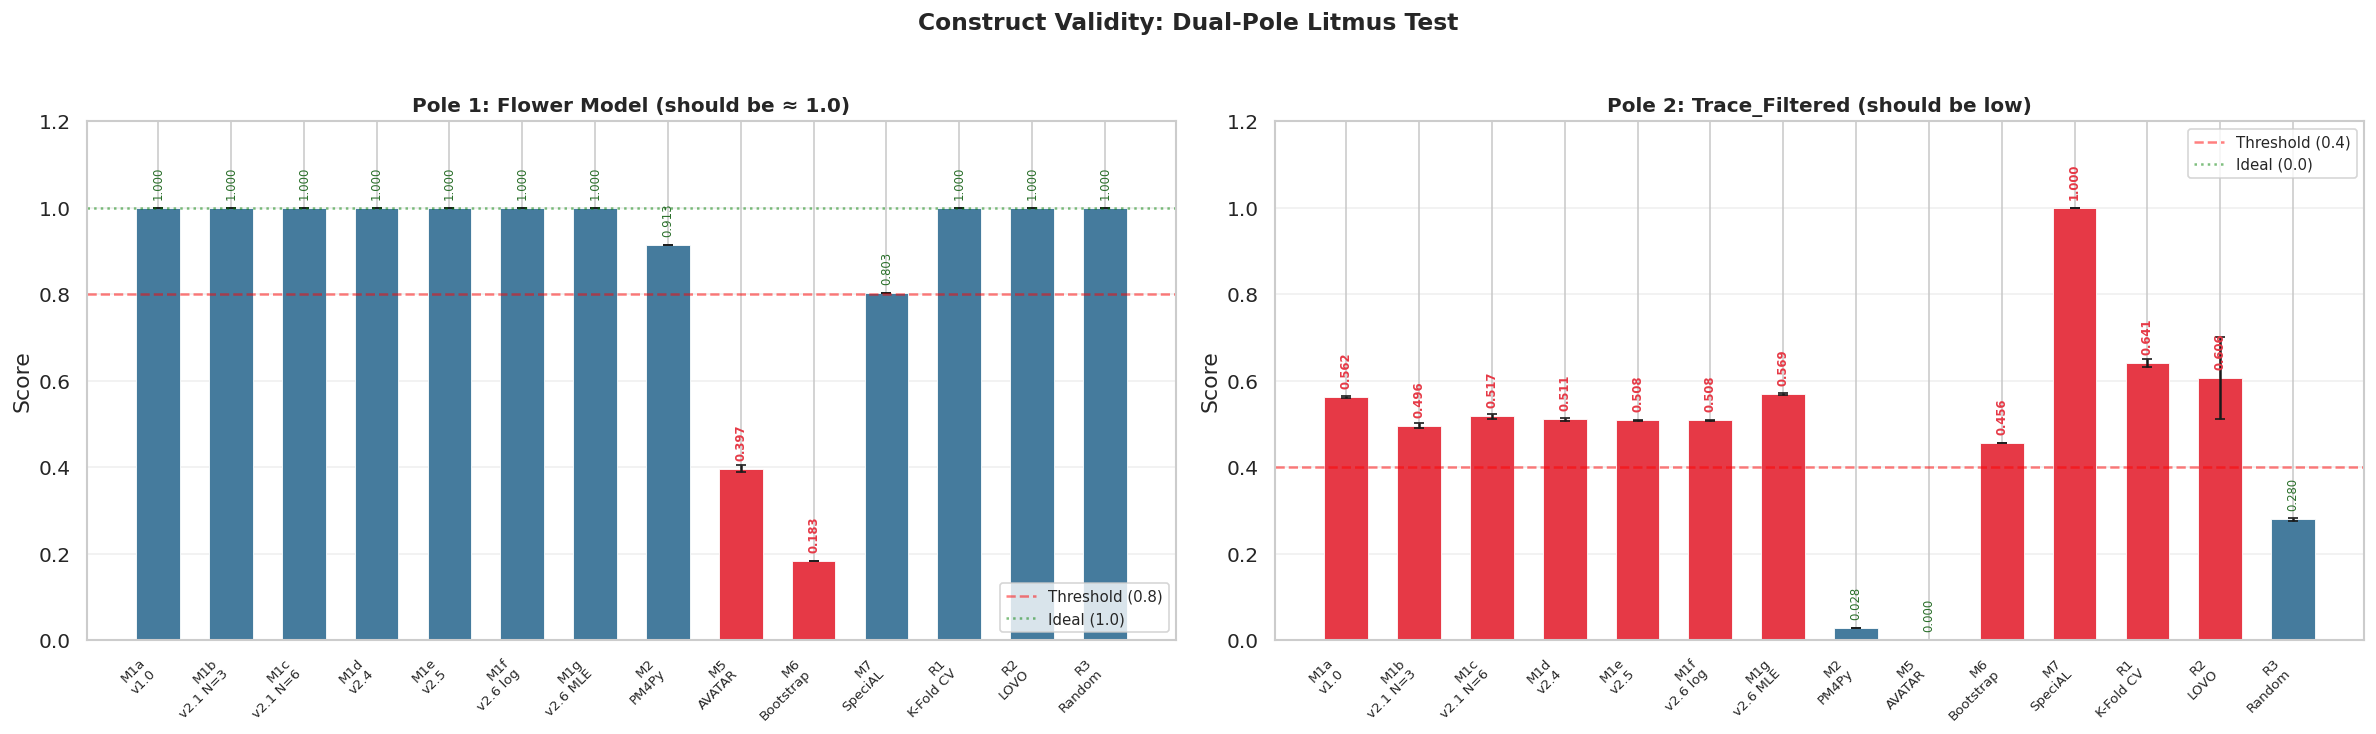

In [24]:
# === Figure 4: Dual-Pole Validation ===
# M3 (DFG-based, unbounded) is excluded — same value across all miners, not on [0,1] scale
all_methods_sorted = [m for m in METHOD_ORDER_ALL if m != 'M3']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Extract Flower and Trace_Filtered scores
flower_vals = pivot_norm.loc['Flower', all_methods_sorted].values
trace_vals = pivot_norm.loc['Trace_Filtered', all_methods_sorted].values
flower_std = pivot_std.loc['Flower', all_methods_sorted].values if 'Flower' in pivot_std.index else None
trace_std = pivot_std.loc['Trace_Filtered', all_methods_sorted].values if 'Trace_Filtered' in pivot_std.index else None

x = np.arange(len(all_methods_sorted))
bar_width = 0.6

# Color bars by threshold check
def bar_colors(vals, threshold, high_bad):
    """high_bad=True: scores ABOVE threshold are red; False: scores BELOW threshold are red"""
    colors = []
    for v in vals:
        if pd.isna(v):
            colors.append('#cccccc')
        elif high_bad:
            colors.append('#E63946' if v > threshold else '#457B9D')
        else:
            colors.append('#E63946' if v < threshold else '#457B9D')
    return colors

# --- Flower subplot (expected ≈ 1.0) ---
fc = bar_colors(flower_vals, 0.8, high_bad=False)
ax1.bar(x, flower_vals, bar_width, color=fc, edgecolor='white', linewidth=0.5,
        yerr=flower_std if flower_std is not None else None, capsize=3)

# Annotate anomalous values
for i, v in enumerate(flower_vals):
    if not pd.isna(v):
        color = '#E63946' if v < 0.8 else '#2a6f2a'
        ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90, color=color, fontweight='bold' if v < 0.8 else 'normal')

ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Threshold (0.8)')
ax1.axhline(y=1.0, color='green', linestyle=':', alpha=0.5, label='Ideal (1.0)')
ax1.set_xticks(x)
ax1.set_xticklabels([METHOD_LABELS.get(m, m) for m in all_methods_sorted], fontsize=8, rotation=45, ha='right')
ax1.set_ylabel('Score')
ax1.set_title('Pole 1: Flower Model (should be ≈ 1.0)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.2)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, axis='y', alpha=0.3)

# --- Trace_Filtered subplot (expected low) ---
tc = bar_colors(trace_vals, 0.4, high_bad=True)
ax2.bar(x, trace_vals, bar_width, color=tc, edgecolor='white', linewidth=0.5,
        yerr=trace_std if trace_std is not None else None, capsize=3)

# Annotate anomalous values
for i, v in enumerate(trace_vals):
    if not pd.isna(v):
        color = '#E63946' if v > 0.4 else '#2a6f2a'
        ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90, color=color, fontweight='bold' if v > 0.4 else 'normal')

ax2.axhline(y=0.4, color='red', linestyle='--', alpha=0.5, label='Threshold (0.4)')
ax2.axhline(y=0.0, color='green', linestyle=':', alpha=0.5, label='Ideal (0.0)')
ax2.set_xticks(x)
ax2.set_xticklabels([METHOD_LABELS.get(m, m) for m in all_methods_sorted], fontsize=8, rotation=45, ha='right')
ax2.set_ylabel('Score')
ax2.set_title('Pole 2: Trace_Filtered (should be low)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.2)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, axis='y', alpha=0.3)

fig.suptitle('Construct Validity: Dual-Pole Litmus Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()